# 保险保费预测 - EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# 保存图表
os.makedirs('images', exist_ok=True)

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

# 读取数据
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.columns = [c.strip().lower().replace(' ', '_') for c in train.columns]
test.columns = [c.strip().lower().replace(' ', '_') for c in test.columns]

print('Train shape:', train.shape)
print('Test shape:', test.shape)

Train shape: (1200000, 21)
Test shape: (800000, 20)


In [2]:
# 缺失值
missing = train.isnull().sum() / len(train) * 100
missing = missing[missing > 0].sort_values(ascending=False)
print('缺失率：')
display(missing)

缺失率：


previous_claims         30.335750
occupation              29.839583
credit_score            11.490167
number_of_dependents     9.139333
customer_feedback        6.485333
health_score             6.173000
annual_income            3.745750
age                      1.558750
marital_status           1.544083
vehicle_age              0.000500
insurance_duration       0.000083
dtype: float64

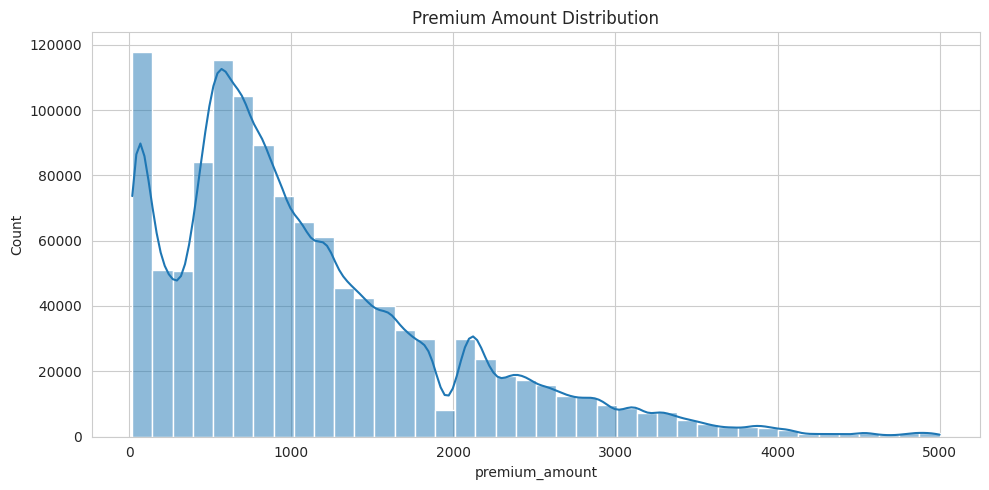

In [3]:
# 目标分布
plt.figure(figsize=(10,5))
sns.histplot(train['premium_amount'], kde=True, bins=40)
plt.title('Premium Amount Distribution')
plt.tight_layout()
plt.savefig('images/target_dist.png', dpi=300)
plt.show()

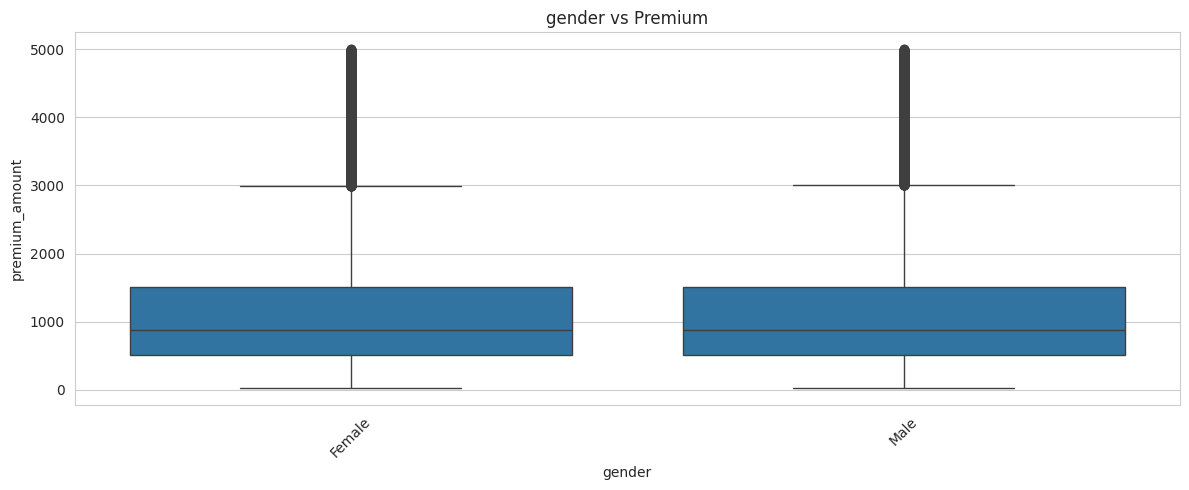

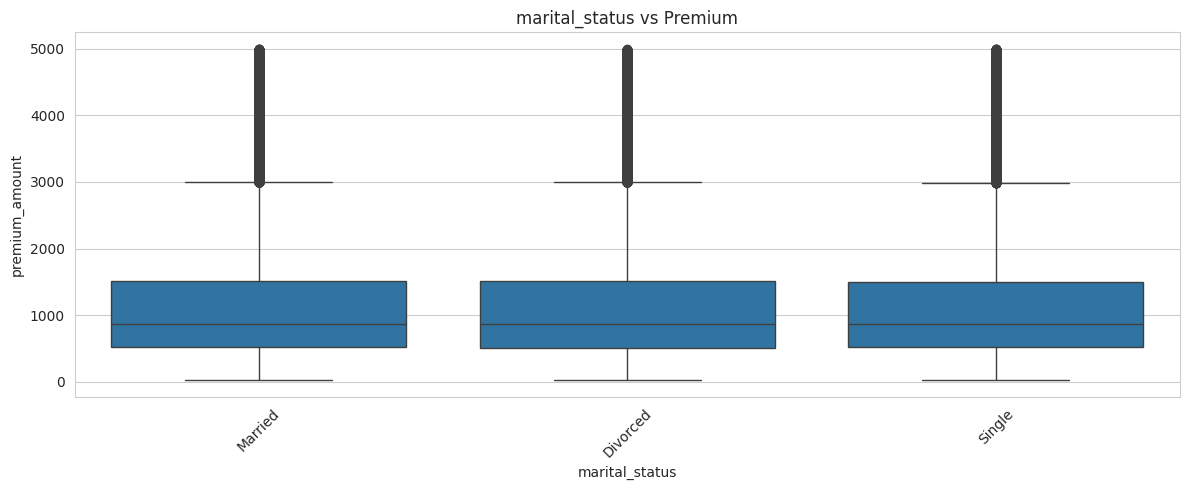

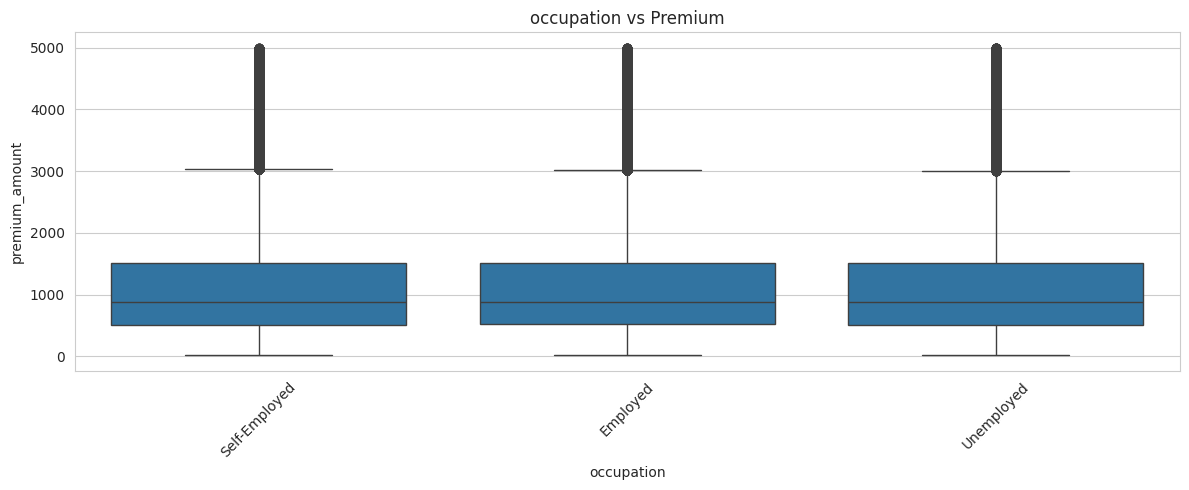

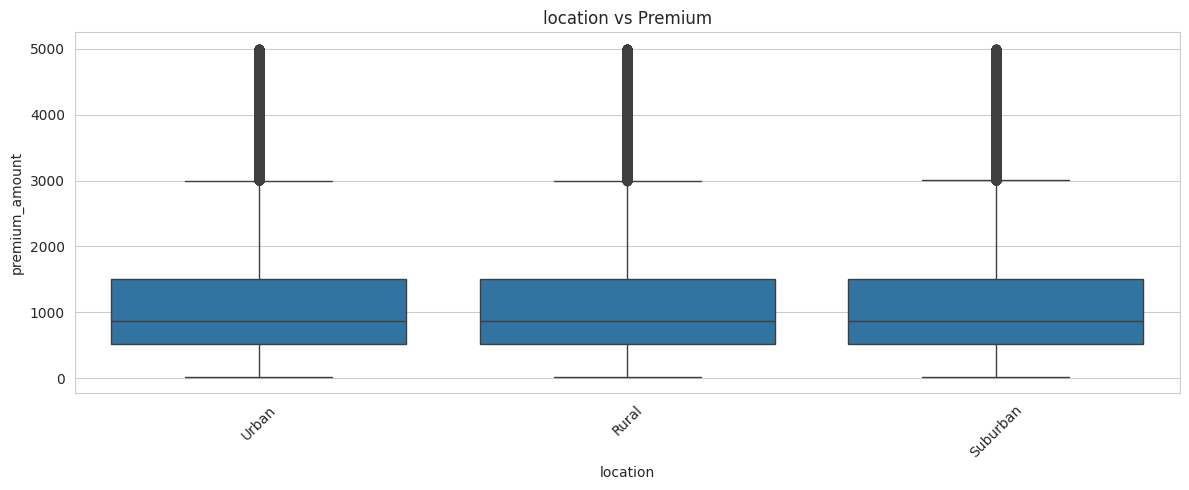

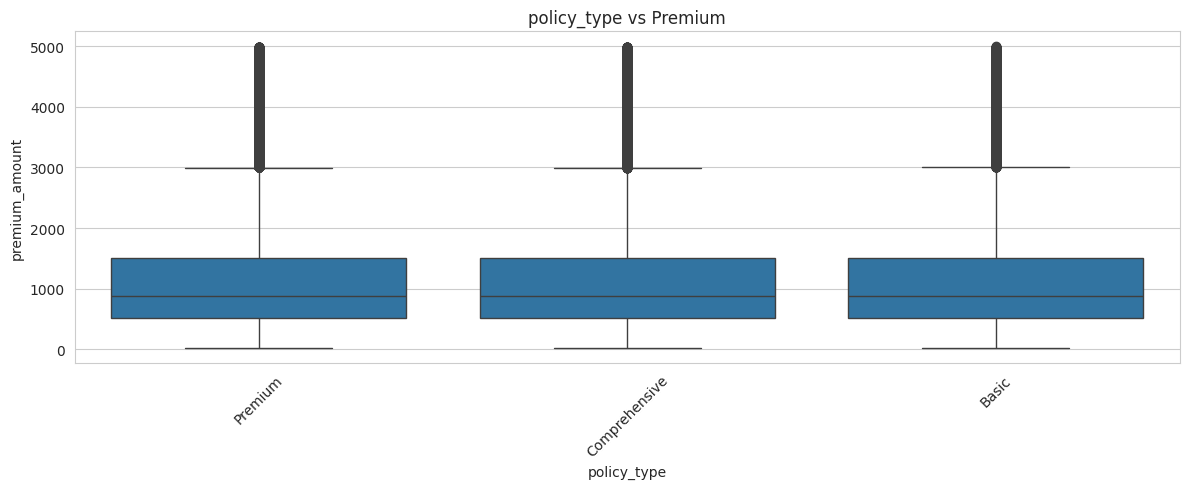

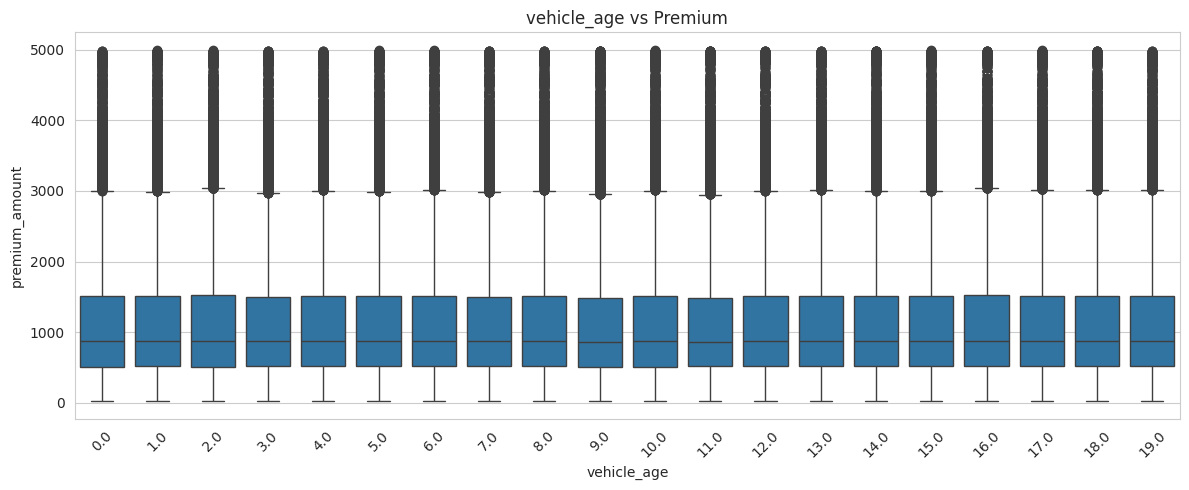

In [4]:
# 类别特征箱线图
cat_cols = ['gender','marital_status','occupation','location','education','policy_type','vehicle_age']
for c in cat_cols:
    if c in train.columns:
        plt.figure(figsize=(12,5))
        sns.boxplot(x=c, y='premium_amount', data=train)
        plt.title(f'{c} vs Premium')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(f'images/cat_{c}.png', dpi=300)
        plt.show()

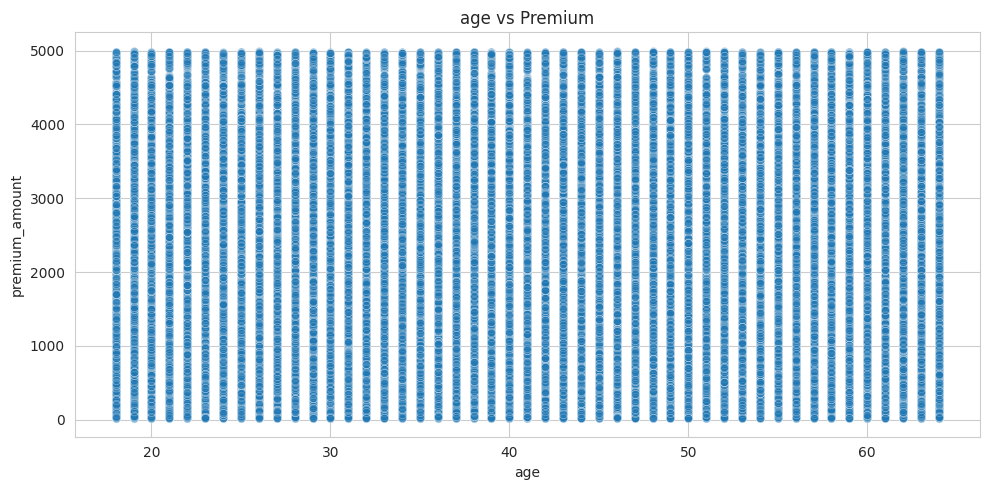

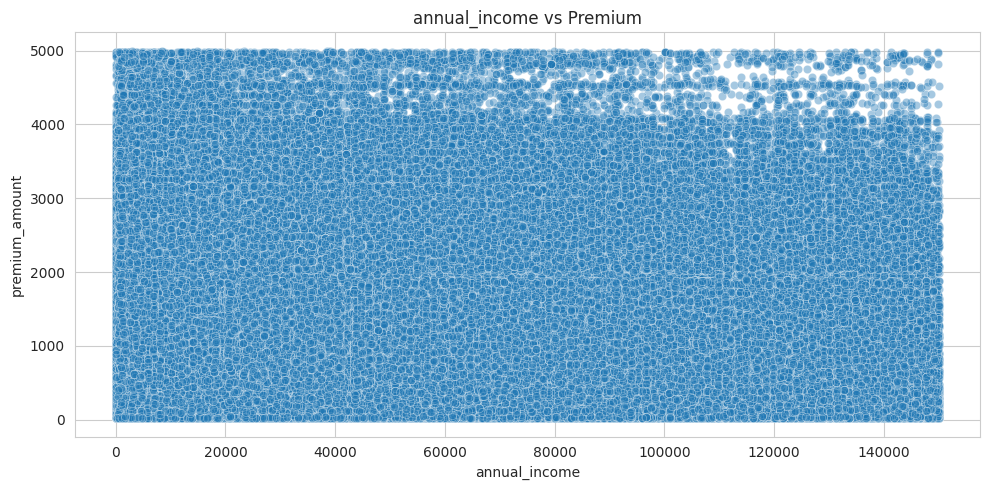

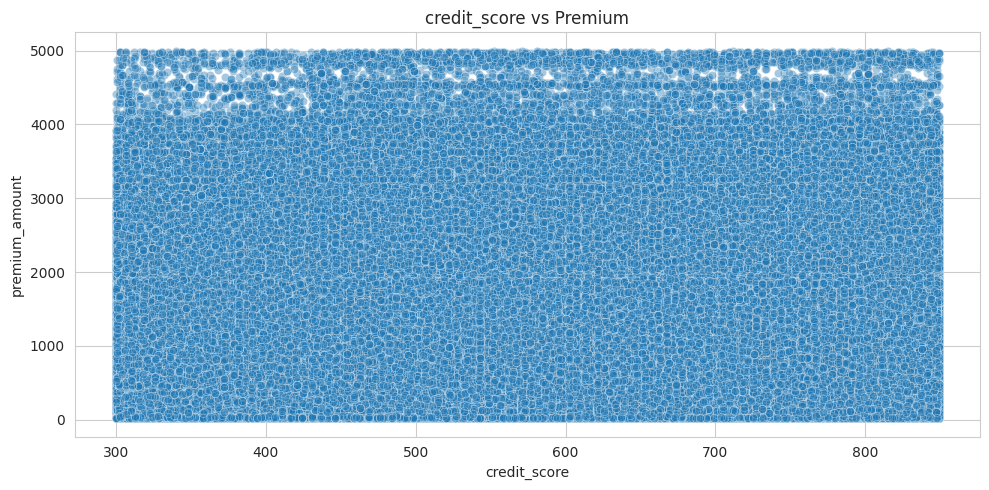

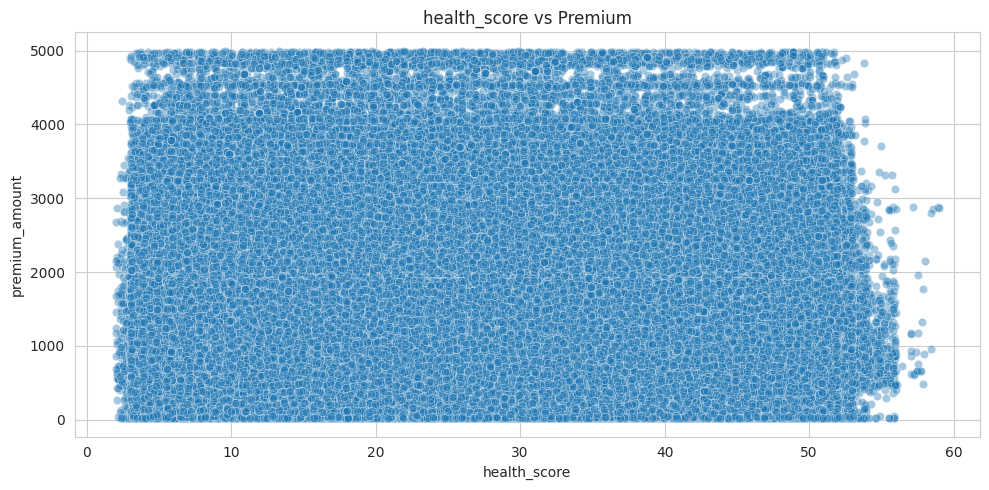

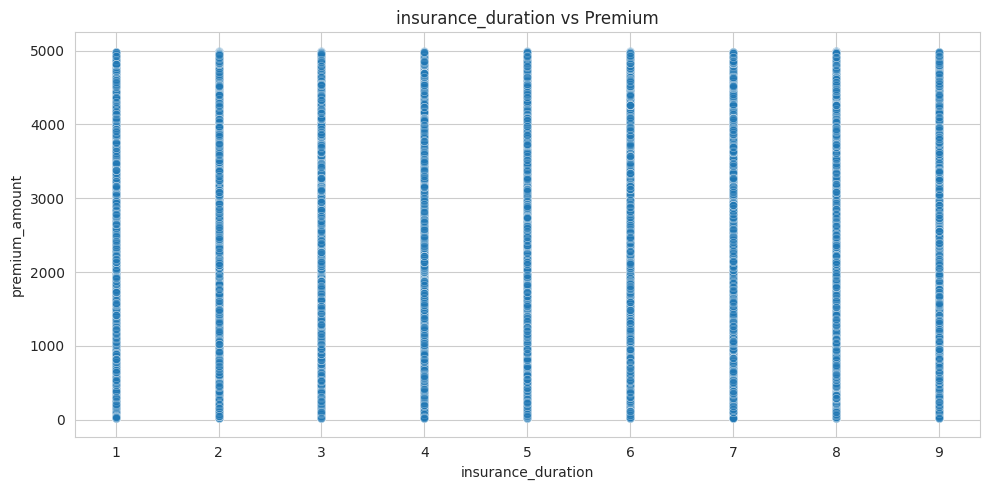

In [5]:
# 数值特征散点图
num_cols = ['age','annual_income','credit_score','health_score','insurance_duration']
for c in num_cols:
    if c in train.columns:
        plt.figure(figsize=(10,5))
        sns.scatterplot(x=c, y='premium_amount', data=train, alpha=0.4)
        plt.title(f'{c} vs Premium')
        plt.tight_layout()
        plt.savefig(f'images/num_{c}.png', dpi=300)
        plt.show()

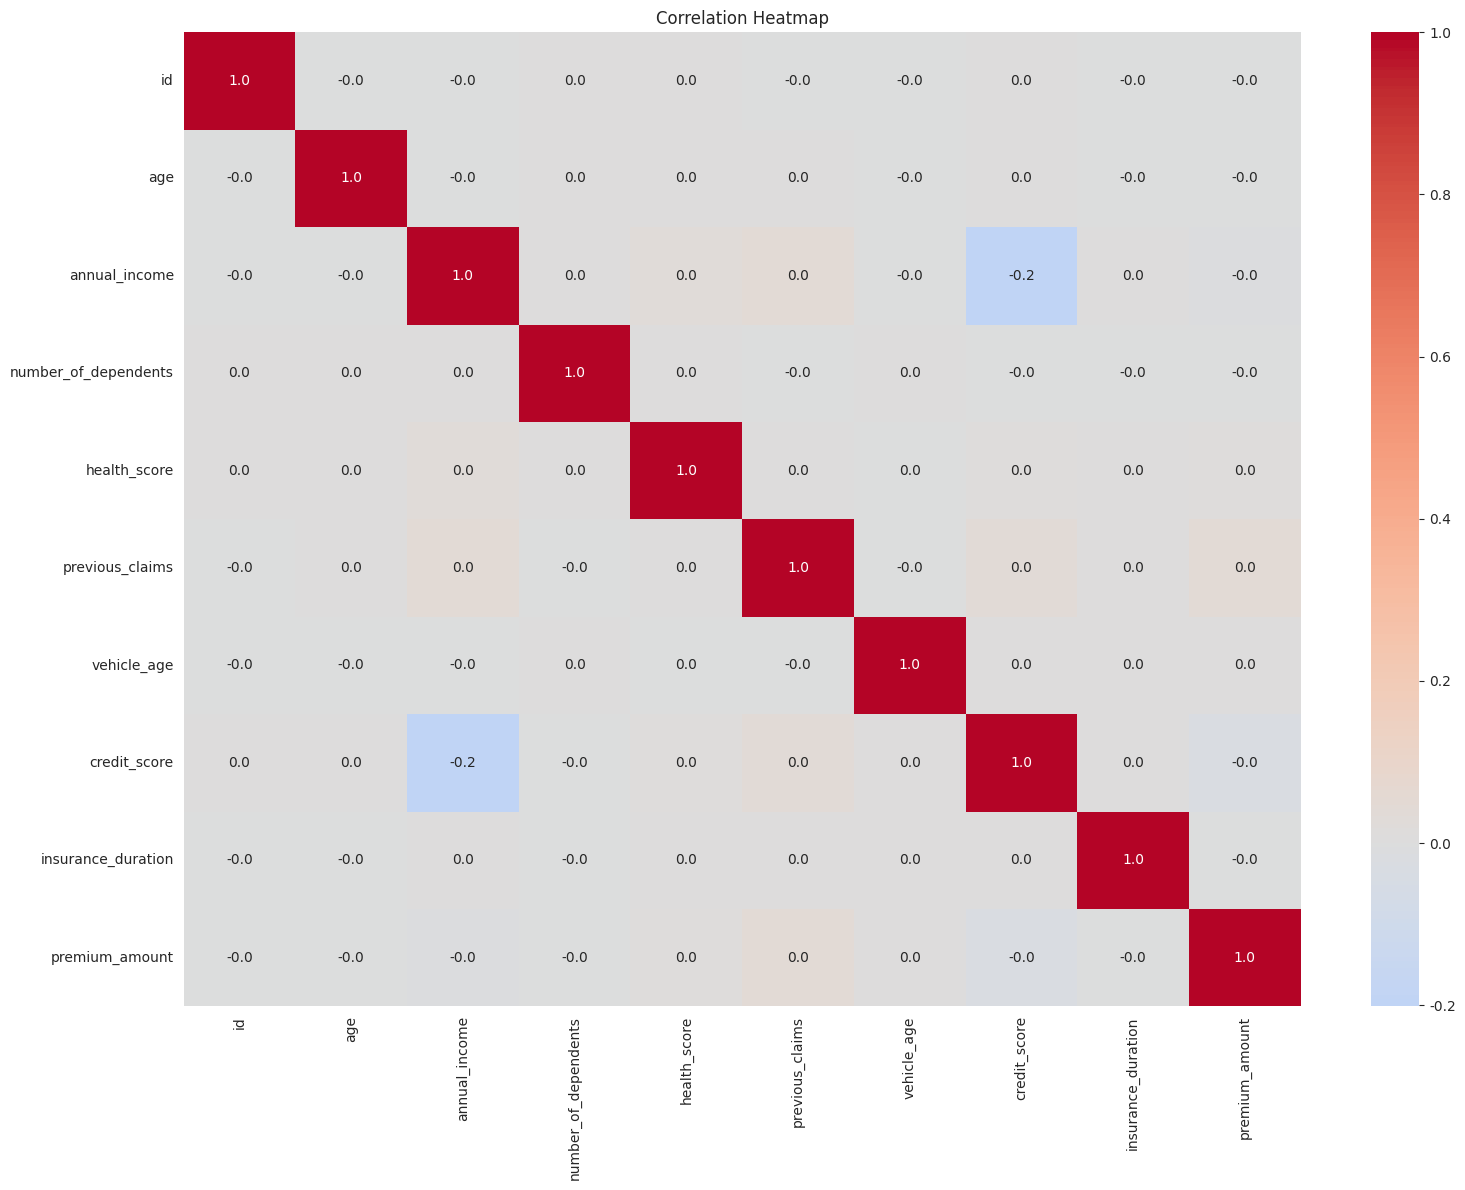

In [6]:
# 相关性热力图
plt.figure(figsize=(16,12))
corr = train.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.1f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('images/correlation.png', dpi=300)
plt.show()